In [7]:
 "# Cell 1 — Install libraries\n"
 !pip install imbalanced-learn xgboost m2cgen -q
 print('Libraries installed ✓')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.2/92.2 kB 3.4 MB/s eta 0:00:00
Libraries installed ✓


In [8]:
#cell 2
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
from google.colab import files
print('select all 4 csv files together')
uploaded = files.upload()



select all 4 csv files together


Saving flowing_uncracked.csv to flowing_uncracked.csv
Saving empty_cracked.csv to empty_cracked.csv
Saving empty_uncracked.csv to empty_uncracked.csv
Saving flowing_cracked.csv to flowing_cracked.csv


from google.colab import files
print('select all 4 csv files together')
uploaded = files.upload()

In [10]:
# 3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from collections import Counter
from xgboost import XGBClassifier
import tensorflow as tf
import m2cgen as m2c
import joblib
import warnings
warnings.filterwarnings('ignore')
print('Imports done ✓')

Imports done ✓


In [11]:

# Cell 3 — Load data with 4 Proper Labels

df1 = pd.read_csv('empty_uncracked.csv')
df1['label'] = 'empty_normal'

df2 = pd.read_csv('empty_cracked.csv')
df2['label'] = 'empty_cracked'

df3 = pd.read_csv('flowing_uncracked.csv')
df3['label'] = 'flowing_normal'

df4 = pd.read_csv('flowing_cracked.csv')
df4['label'] = 'flowing_cracked'

combined = pd.concat([df1, df2, df3, df4], ignore_index=True)

print('Raw data shape:', combined.shape)
print('\n=== 4 Labels in Dataset ===')
print(combined['label'].value_counts())



Raw data shape: (1029, 4)

=== 4 Labels in Dataset ===
label
flowing_cracked    329
empty_normal       269
flowing_normal     229
empty_cracked      202
Name: count, dtype: int64


In [ ]:
combined.to_excel("final_processed_dataset1.xlsx", index=False)
print("Clean dataset saved to Excel with positive raw amplitudes and normalized frequency! \u2713")

Clean dataset saved to Excel with positive raw amplitudes and normalized frequency! ✓


In [12]:
# 1. Initialize and apply the Label Encoder (Maps classes to 0, 1, 2, 3)
label_encoder = LabelEncoder()
combined['label_encoded'] = label_encoder.fit_transform(combined['label'])

# Save the label encoder right away so you can decode predictions later
joblib.dump(label_encoder, 'label_encoder.pkl')

print("=== LABEL MAPPING MAP ===")
for index, class_name in enumerate(label_encoder.classes_):
    print(f"Class '{class_name}' ---> Encoded Label: {index}")
print("=========================\n")


# 2. Perform a Stratified Split (90% Train + Validation, 10% Test)
# We stratify on 'label_encoded' to keep class distributions perfectly balanced
train_val_df, test_df = train_test_split(
    combined,
    test_size=0.10,
    stratify=combined['label_encoded'],
    random_state=42
)

# 3. Split the 90% Train + Validation set into individual sets (e.g., 80% Train, 10% Val of the remainder)
# This creates a crisp three-way split: Train, Validation, and Test
train_df, val_df = train_test_split(
    train_val_df,
    test_size=1/9,  # 10% of the 90% goes to validation
    stratify=train_val_df['label_encoded'],
    random_state=42
)

# 4. Verify the exact row counts for each split
print("=== SPLIT DISTRIBUTION CORES ===")
print(f"Training Set Size   : {len(train_df)} rows")
print(f"Validation Set Size : {len(val_df)} rows")
print(f"Testing Set Size    : {len(test_df)} rows")
print(combined['label'].value_counts())


=== LABEL MAPPING MAP ===
Class 'empty_cracked' ---> Encoded Label: 0
Class 'empty_normal' ---> Encoded Label: 1
Class 'flowing_cracked' ---> Encoded Label: 2
Class 'flowing_normal' ---> Encoded Label: 3

=== SPLIT DISTRIBUTION CORES ===
Training Set Size   : 823 rows
Validation Set Size : 103 rows
Testing Set Size    : 103 rows
label
flowing_cracked    329
empty_normal       269
flowing_normal     229
empty_cracked      202
Name: count, dtype: int64


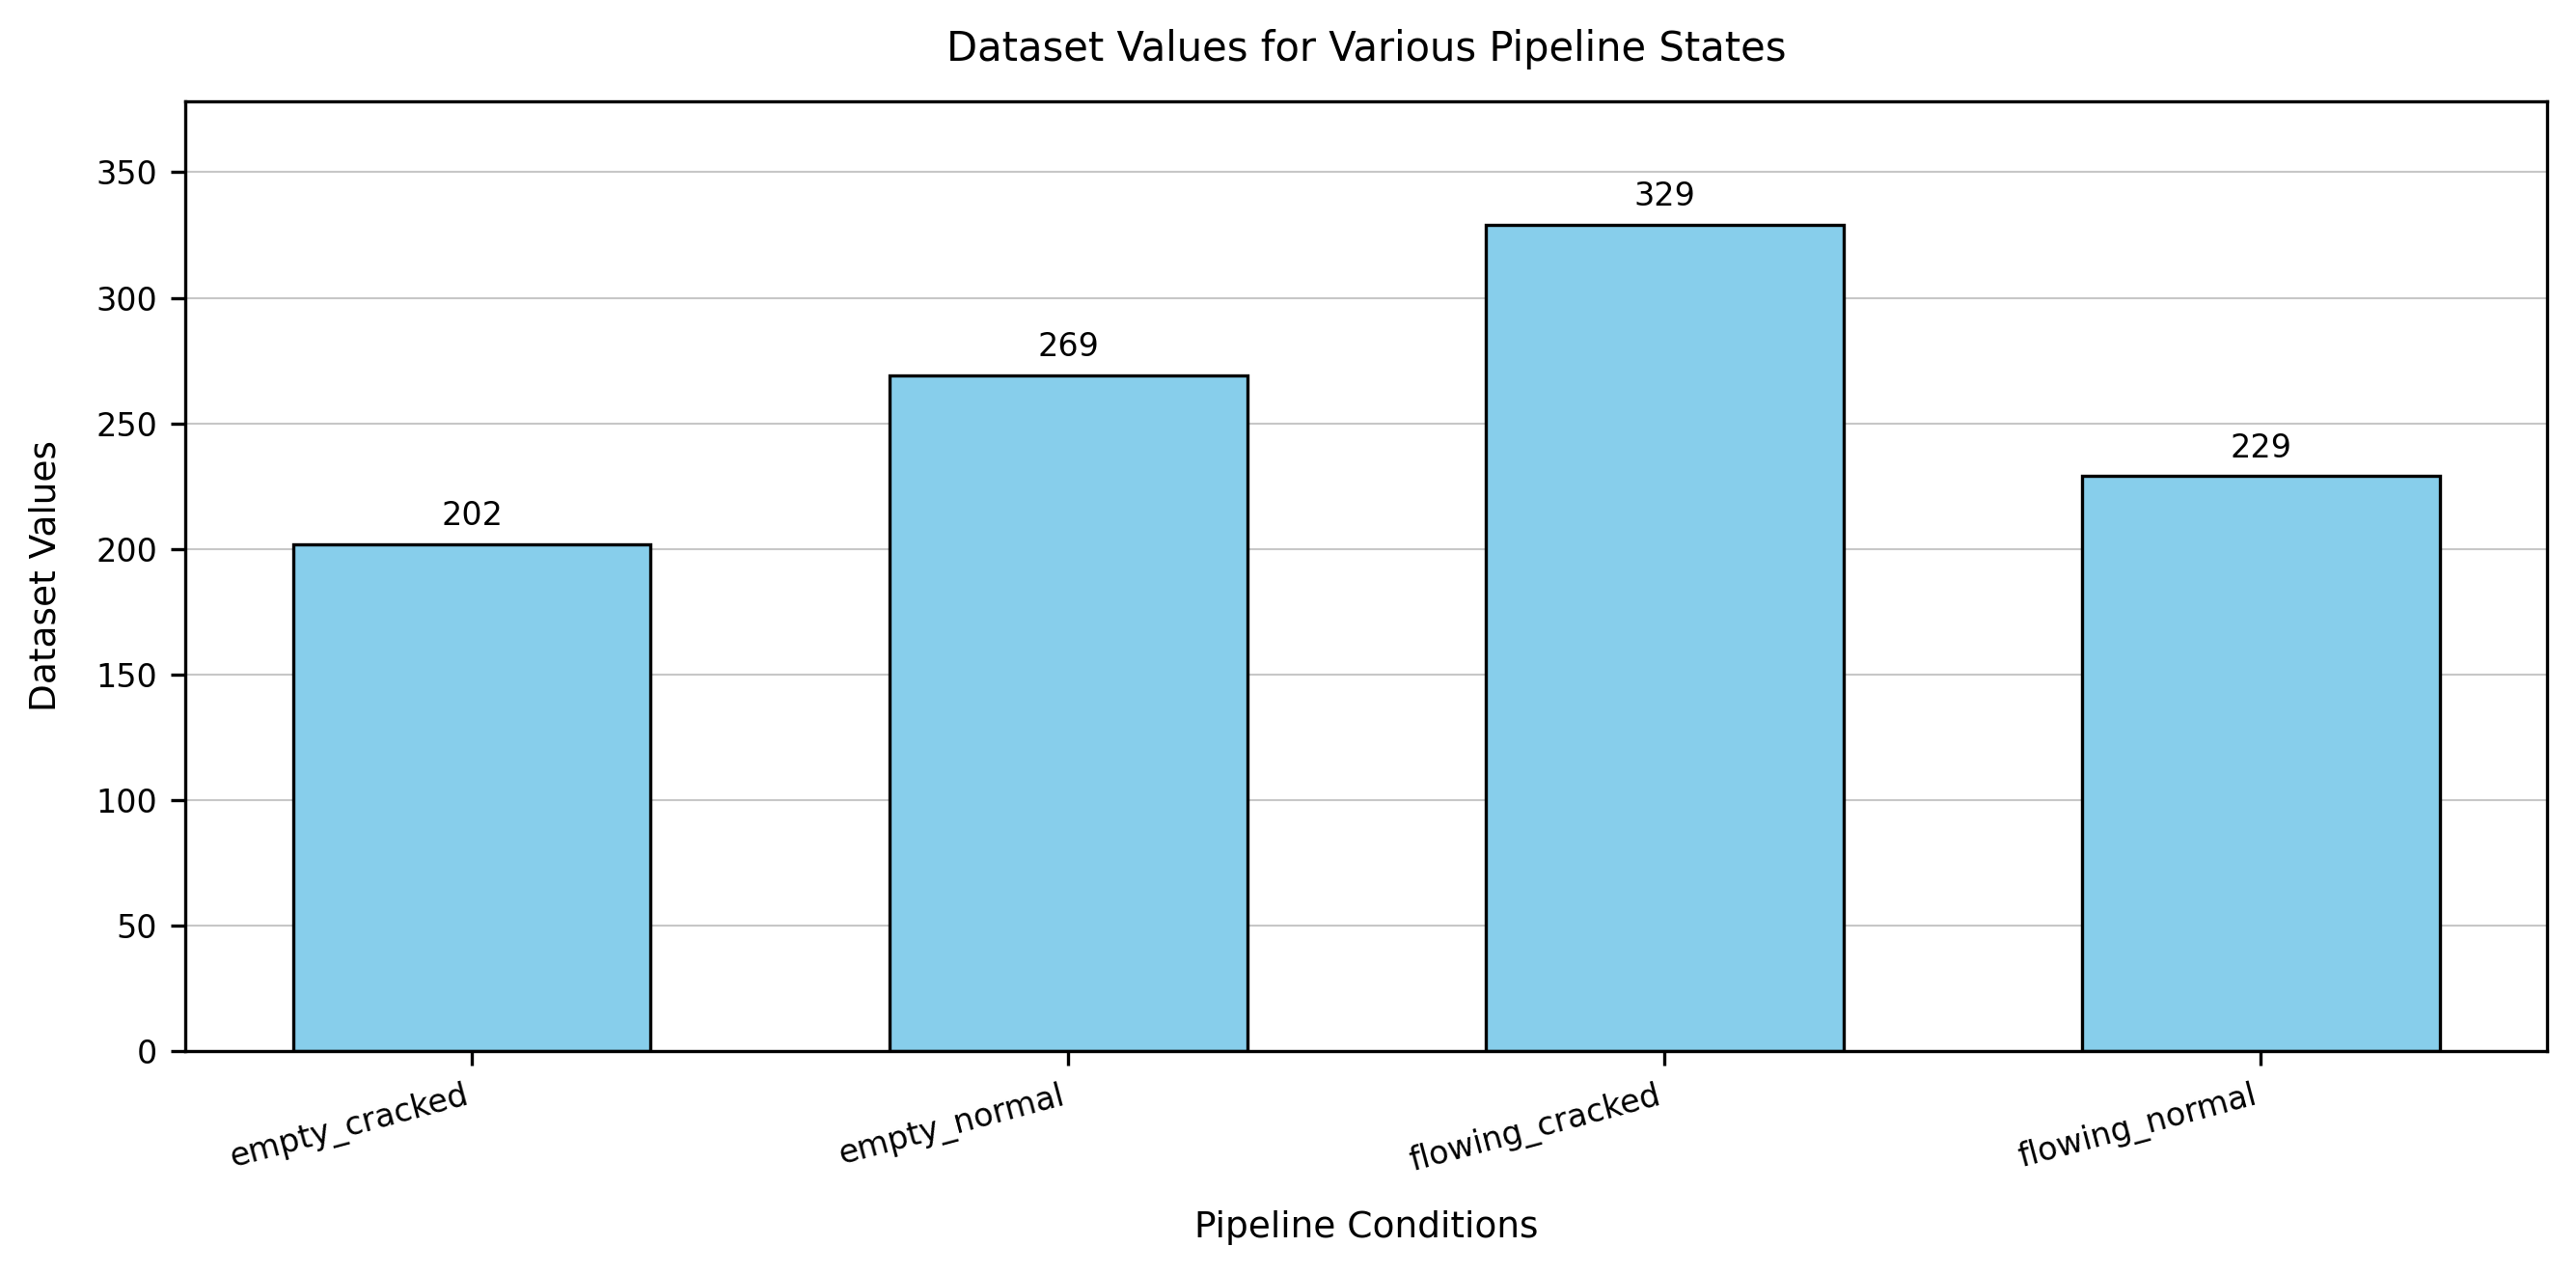

✓ Saved matching bar graph template to: pipeline_data_distribution.png


In [13]:
import matplotlib.pyplot as plt

# Ensure high-resolution rendering configurations
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# Explicit order matching your pipeline states
ordered_classes = ['empty_cracked', 'empty_normal', 'flowing_cracked', 'flowing_normal']
class_counts = combined['label'].value_counts().reindex(ordered_classes)

# Match the plot dimensions of the reference image 1000031491.jpg
fig, ax = plt.subplots(figsize=(9, 4.5))

# 1. Plot bars matching the exact visual style: light sky blue with distinct thin black borders
bar_color = '#87CEEB'  # Sky blue color matching image 1000031491.jpg
bars = ax.bar(class_counts.index, class_counts.values, color=bar_color, edgecolor='black', linewidth=0.8, width=0.6)

# 2. Add the count values directly centered over each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + (max(class_counts.values) * 0.015),
            f'{int(yval)}', ha='center', va='bottom', fontsize=8)

# 3. Apply exact title, axis labels, and layout ticks from the reference image
ax.set_title('Dataset Values for Various Pipeline States', fontsize=10, pad=10)
ax.set_xlabel('Pipeline Conditions', fontsize=9, labelpad=8)
ax.set_ylabel('Dataset Values', fontsize=9, labelpad=8)

# Format ticks and boundaries to keep it looking clear
ax.set_xticklabels(ordered_classes, rotation=15, ha='right', fontsize=8)
ax.tick_params(axis='y', labelsize=8)

# Set grid line styling matching the background style of image 1000031491.jpg
ax.grid(axis='y', linestyle='-', linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True) # Keeps gridlines behind the bars

# Adjust y-limit dynamically to give head clearance for text numbers
ax.set_ylim(0, max(class_counts.values) * 1.15)

plt.tight_layout()

# 4. Save directly as a clean, un-truncated PNG file to your sidebar workspace
output_filename = "pipeline_data_distribution.png"
plt.savefig(output_filename, bbox_inches='tight', dpi=300)
plt.show()

print(f"✓ Saved matching bar graph template to: {output_filename}")

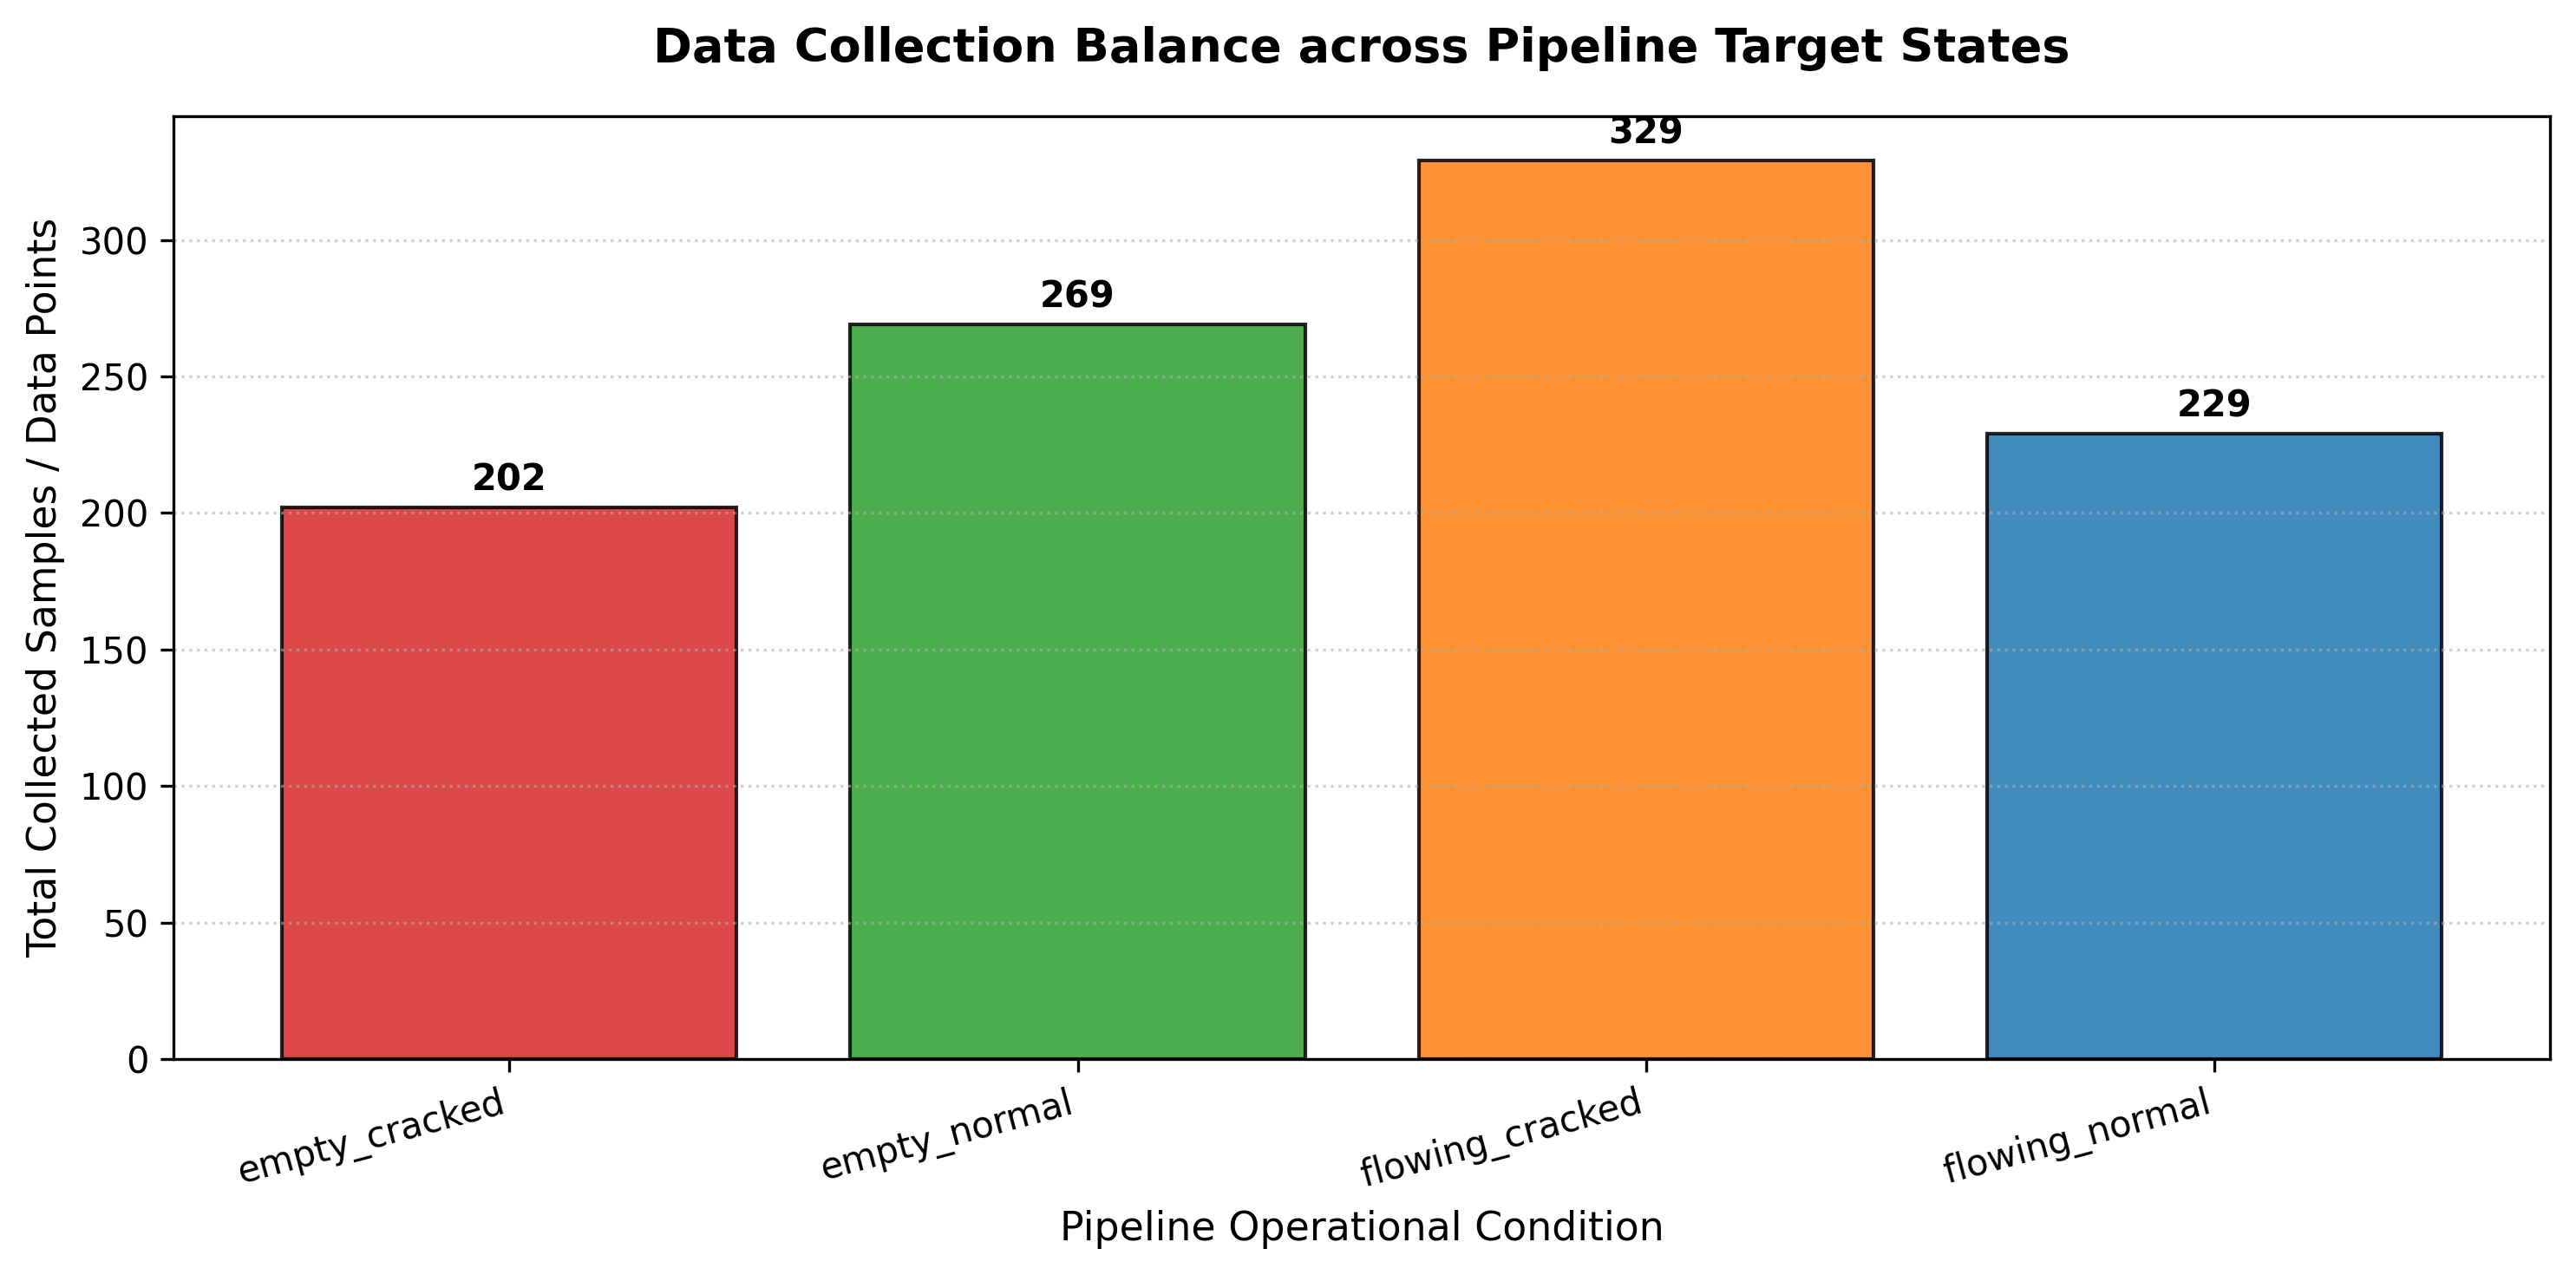

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure standard ordering for presentation consistency
ordered_classes = ['empty_cracked', 'empty_normal', 'flowing_cracked', 'flowing_normal']
class_counts = combined['label'].value_counts().reindex(ordered_classes)

plt.figure(figsize=(10, 5))

# Create custom palette matching your previous evaluation plots
colors = ['#d62728', '#2ca02c', '#ff7f0e', '#1f77b4'] # Red, Green, Orange, Blue

bars = plt.bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', alpha=0.85)

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(class_counts.values)*0.01),
             f'{int(yval):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Data Collection Balance across Pipeline Target States', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Pipeline Operational Condition', fontsize=11)
plt.ylabel('Total Collected Samples / Data Points', fontsize=11)
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

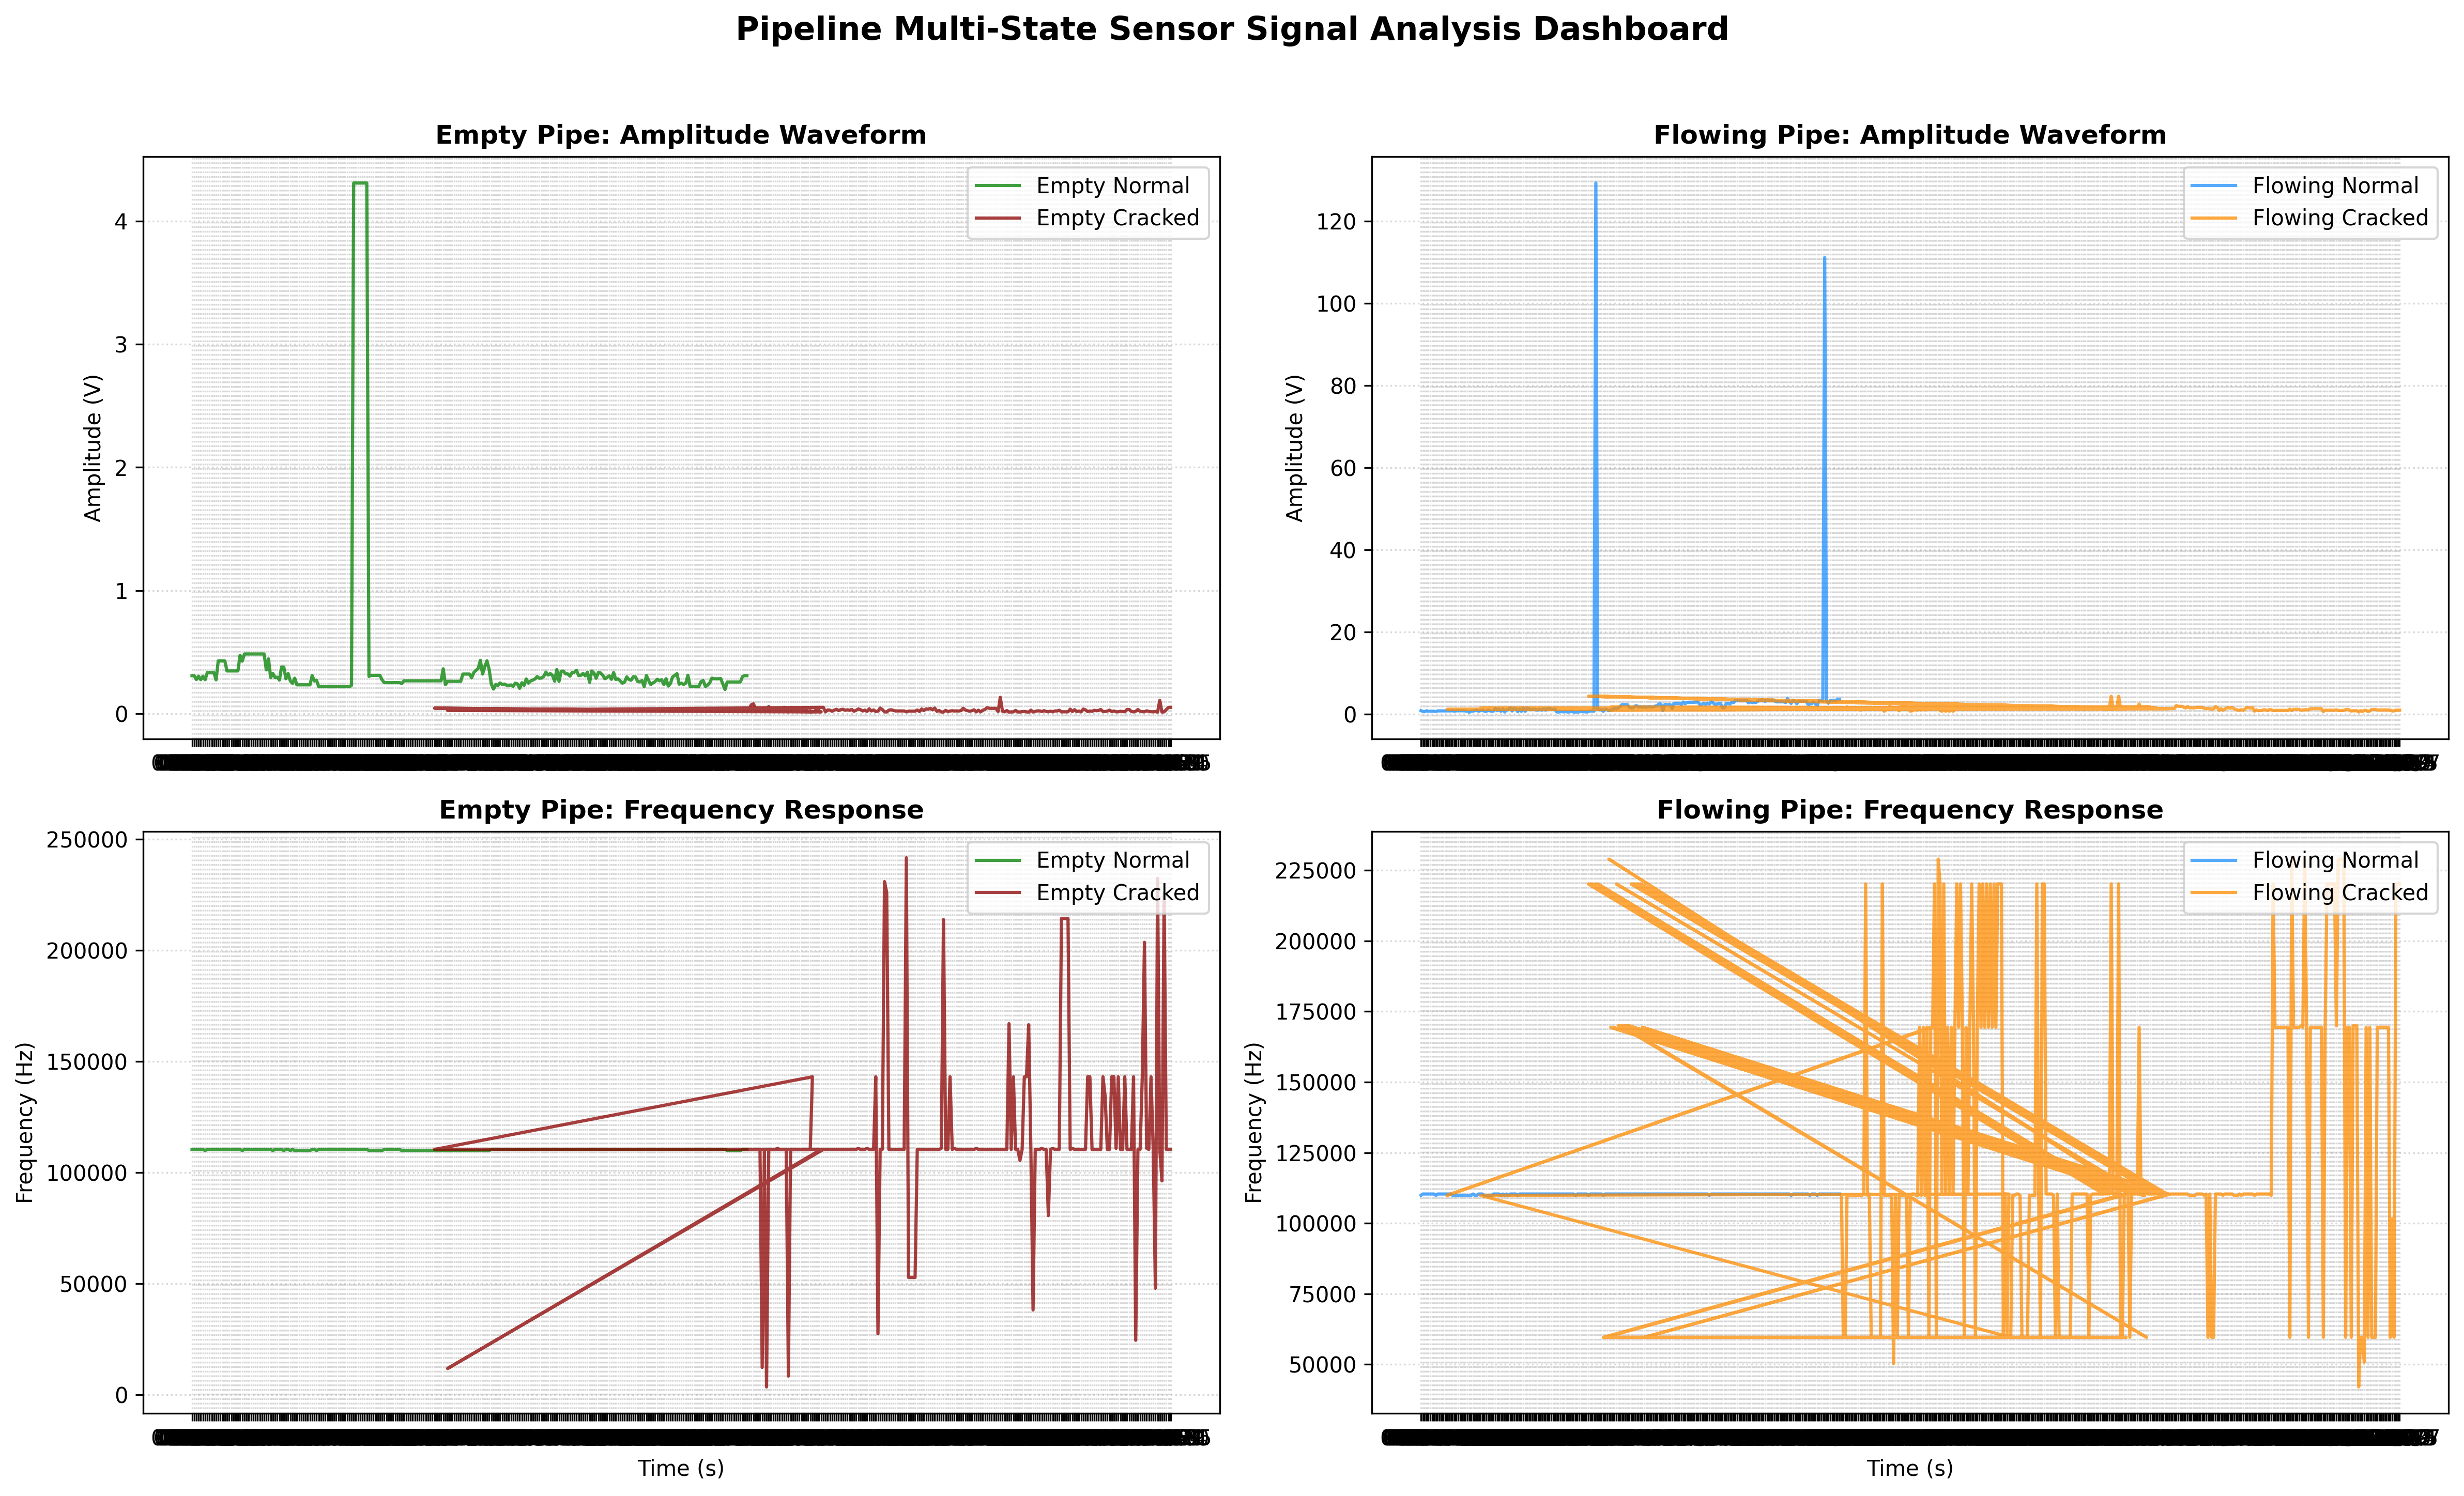

In [15]:
import matplotlib.pyplot as plt

# 1. Create a 2x2 multi-panel layout canvas
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
fig.suptitle("Pipeline Multi-State Sensor Signal Analysis Dashboard", fontsize=15, fontweight='bold', y=0.96)

# Split data by state configurations for clear overlapping plots
empty_normal = combined[combined['label'] == 'empty_normal'].sort_values('timestamp')
empty_cracked = combined[combined['label'] == 'empty_cracked'].sort_values('timestamp')
flowing_normal = combined[combined['label'] == 'flowing_normal'].sort_values('timestamp')
flowing_cracked = combined[combined['label'] == 'flowing_cracked'].sort_values('timestamp')

# ---------------------------------------------------------------------
# PANEL [0, 0]: EMPTY STATE - AMPLITUDE VS TIME
# ---------------------------------------------------------------------
axes[0, 0].plot(empty_normal['timestamp'], empty_normal['amplitude'], label='Empty Normal', color='green', alpha=0.75, linewidth=1.5)
axes[0, 0].plot(empty_cracked['timestamp'], empty_cracked['amplitude'], label='Empty Cracked', color='darkred', alpha=0.75, linewidth=1.5)
axes[0, 0].set_title('Empty Pipe: Amplitude Waveform', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Amplitude (V)', fontsize=10)
axes[0, 0].grid(True, linestyle=':', alpha=0.5)
axes[0, 0].legend(loc='upper right')

# ---------------------------------------------------------------------
# PANEL [0, 1]: FLOWING STATE - AMPLITUDE VS TIME
# ---------------------------------------------------------------------
axes[0, 1].plot(flowing_normal['timestamp'], flowing_normal['amplitude'], label='Flowing Normal', color='dodgerblue', alpha=0.75, linewidth=1.5)
axes[0, 1].plot(flowing_cracked['timestamp'], flowing_cracked['amplitude'], label='Flowing Cracked', color='darkorange', alpha=0.75, linewidth=1.5)
axes[0, 1].set_title('Flowing Pipe: Amplitude Waveform', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Amplitude (V)', fontsize=10)
axes[0, 1].grid(True, linestyle=':', alpha=0.5)
axes[0, 1].legend(loc='upper right')

# ---------------------------------------------------------------------
# PANEL [1, 0]: EMPTY STATE - FREQUENCY VS TIME
# ---------------------------------------------------------------------
axes[1, 0].plot(empty_normal['timestamp'], empty_normal['frequency'], label='Empty Normal', color='green', alpha=0.75, linewidth=1.5)
axes[1, 0].plot(empty_cracked['timestamp'], empty_cracked['frequency'], label='Empty Cracked', color='darkred', alpha=0.75, linewidth=1.5)
axes[1, 0].set_title('Empty Pipe: Frequency Response', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Time (s)', fontsize=10)
axes[1, 0].set_ylabel('Frequency (Hz)', fontsize=10)
axes[1, 0].grid(True, linestyle=':', alpha=0.5)
axes[1, 0].legend(loc='upper right')

# ---------------------------------------------------------------------
# PANEL [1, 1]: FLOWING STATE - FREQUENCY VS TIME
# ---------------------------------------------------------------------
axes[1, 1].plot(flowing_normal['timestamp'], flowing_normal['frequency'], label='Flowing Normal', color='dodgerblue', alpha=0.75, linewidth=1.5)
axes[1, 1].plot(flowing_cracked['timestamp'], flowing_cracked['frequency'], label='Flowing Cracked', color='darkorange', alpha=0.75, linewidth=1.5)
axes[1, 1].set_title('Flowing Pipe: Frequency Response', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Time (s)', fontsize=10)
axes[1, 1].set_ylabel('Frequency (Hz)', fontsize=10)
axes[1, 1].grid(True, linestyle=':', alpha=0.5)
axes[1, 1].legend(loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
import joblib

# ========================================================
# 1. LABEL ENCODING & STRATIFIED SPLITTING (80/10/10)
# ========================================================

# Encode classes (empty_normal, empty_cracked, etc.) to 0, 1, 2, 3
label_encoder = LabelEncoder()
combined['label_encoded'] = label_encoder.fit_transform(combined['label'])

# Save encoder so you can decode predictions during testing/inference later
joblib.dump(label_encoder, 'label_encoder.pkl')

print("=== 1. LABEL MAPPING ===")
for index, class_name in enumerate(label_encoder.classes_):
    print(f"Class '{class_name}' ---> Encoded Label: {index}")
print("=========================\n")

# First Split: Isolate 10% for the strict Test Set
train_val_df, test_df = train_test_split(
    combined,
    test_size=0.10,
    stratify=combined['label_encoded'],
    random_state=42
)

# Second Split: Break down remaining 90% into 80% Train and 10% Validation
# (1/9 of 90% equals exactly 10% of the original overall total)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=1/9,
    stratify=train_val_df['label_encoded'],
    random_state=42
)


# ========================================================
# 2. LEAKAGE-FREE FEATURE EXTRACTION ENGINE
# ========================================================

def extract_optimal_features(df, train_global_floor=None):
    # Create a deep copy to prevent slice assignment warnings
    df = df.copy()

    NYQUIST = 250000  # 500,000 Hz / 2
    window = 10

    # Frequency Normalization (keeps values scaled smoothly between 0 and 1)
    df['freq_normalized'] = df['frequency'] / NYQUIST

    # Localized Rolling Window Statistics calculated within this specific split
    for label in df['label'].unique():
        mask = df['label'] == label
        amp = df.loc[mask, 'amplitude']
        df.loc[mask, 'amp_mean'] = amp.rolling(window, min_periods=1).mean()
        df.loc[mask, 'amp_std']  = amp.rolling(window, min_periods=1).std().fillna(0)

    # Volatility & Point-to-Point Difference Features
    df['amp_cv']   = df['amp_std'] / (df['amp_mean'] + 1e-9)
    df['amp_diff'] = df.groupby('label')['amplitude'].transform(lambda x: x.diff().abs().fillna(0))

    # --- DUAL SNR PROCESSING ---
    # Perspective A: Global SNR Baseline (20dB-30dB Macro Scale)
    if train_global_floor is None:
        # If processing the Train Split, compute the calibration floor here
        train_global_floor = np.percentile(df['amplitude'], 5)

    # Validation and Test sets use the exact calibration floor calculated from Train
    df['snr_global'] = 20 * np.log10(df['amplitude'] / (train_global_floor + 1e-9))

    # Perspective B: Grouped SNR Baseline (0dB-10dB Micro-Crack Scale)
    df['snr_grouped'] = df.groupby('label')['amplitude'].transform(
        lambda x: 20 * np.log10(x / (np.percentile(x, 5) + 1e-9))
    )

    # Select only the non-redundant, highly-predictive feature columns
    feature_columns = [
        'amplitude', 'freq_normalized', 'amp_mean',
        'amp_std', 'amp_cv', 'amp_diff', 'snr_global', 'snr_grouped'
    ]

    return df[feature_columns].values, df['label_encoded'].values, train_global_floor


# Run feature extraction on each split independently
X_train_raw, y_train, train_floor = extract_optimal_features(train_df)
X_val_raw, y_val, _              = extract_optimal_features(val_df, train_global_floor=train_floor)
X_test_raw, y_test, _            = extract_optimal_features(test_df, train_global_floor=train_floor)


# ========================================================
# 3. ROBUST SCALING & TRAINING-SET SMOTE BALANCING
# ========================================================

# Fit the scaler STRICTLY on the training features matrix
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)

# Transform Validation and Test features with the training configuration parameters
X_val_scaled  = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Save the configured scaler for live production/deployment predictions later
joblib.dump(scaler, 'scaler.pkl')

# Balance class frequencies using SMOTE ONLY on the training sets
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(combined['label'].value_counts())



# ========================================================
# 4. FINAL PIPELINE VERIFICATION METRICS
# ========================================================

print("=== 2. SPLIT & FEATURE SUMMARY ===")
print(f"Original Clean Dataset Rows : {len(combined)}")
print(f"Features Engineered         : {X_train_raw.shape[1]} optimal dimensions\n")

print(combined['label'].value_counts())

print("=== 3. ARRAYS SHAPES FOR MODEL TRAINING ===")
print(f"X_train_resampled (Balanced via SMOTE) : {X_train_resampled.shape} | y_train_resampled: {y_train_resampled.shape}")
print(f"X_val_scaled      (Validation Set)     : {X_val_scaled.shape}   | y_val: {y_val.shape}")
print(f"X_test_scaled     (Testing Set)        : {X_test_scaled.shape}   | y_test: {y_test.shape}")
print("===========================================")
print("✔ Pipeline Executed Cleanly! Variables are isolated and ready for your models.")

=== 1. LABEL MAPPING ===
Class 'empty_cracked' ---> Encoded Label: 0
Class 'empty_normal' ---> Encoded Label: 1
Class 'flowing_cracked' ---> Encoded Label: 2
Class 'flowing_normal' ---> Encoded Label: 3

label
flowing_cracked    329
empty_normal       269
flowing_normal     229
empty_cracked      202
Name: count, dtype: int64
=== 2. SPLIT & FEATURE SUMMARY ===
Original Clean Dataset Rows : 1029
Features Engineered         : 8 optimal dimensions

label
flowing_cracked    329
empty_normal       269
flowing_normal     229
empty_cracked      202
Name: count, dtype: int64
=== 3. ARRAYS SHAPES FOR MODEL TRAINING ===
X_train_resampled (Balanced via SMOTE) : (1052, 8) | y_train_resampled: (1052,)
X_val_scaled      (Validation Set)     : (103, 8)   | y_val: (103,)
X_test_scaled     (Testing Set)        : (103, 8)   | y_test: (103,)
✔ Pipeline Executed Cleanly! Variables are isolated and ready for your models.


In [17]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import joblib

def extract_optimal_features(df, train_global_floor=None):
    # Create a deep copy to prevent slice assignment warnings
    df = df.copy()

    NYQUIST = 250000  # 500,000 Hz / 2
    window = 10

    # Frequency Normalization (keeps values scaled smoothly between 0 and 1)
    df['freq_normalized'] = df['frequency'] / NYQUIST

    # Localized Rolling Window Statistics calculated within this specific split
    for label in df['label'].unique():
        mask = df['label'] == label
        amp = df.loc[mask, 'amplitude']
        df.loc[mask, 'amp_mean'] = amp.rolling(window, min_periods=1).mean()
        df.loc[mask, 'amp_std']  = amp.rolling(window, min_periods=1).std().fillna(0)

        # --- NEW PARAMETERS ADDED ---
        # 1. Rolling Root Mean Square (RMS)
        df.loc[mask, 'rms'] = np.sqrt(amp.pow(2).rolling(window, min_periods=1).mean())
        # 2. Rolling Kurtosis (Peak sharpness metric)
        df.loc[mask, 'kurtosis'] = amp.rolling(window, min_periods=1).kurt().fillna(0)

    # Volatility & Point-to-Point Difference Features
    df['amp_cv']   = df['amp_std'] / (df['amp_mean'] + 1e-9)
    df['amp_diff'] = df.groupby('label')['amplitude'].transform(lambda x: x.diff().abs().fillna(0))

    # --- DUAL SNR PROCESSING ---
    if train_global_floor is None:
        train_global_floor = np.percentile(df['amplitude'], 5)

    df['snr_global'] = 20 * np.log10(df['amplitude'] / (train_global_floor + 1e-9))

    df['snr_grouped'] = df.groupby('label')['amplitude'].transform(
        lambda x: 20 * np.log10(x / (np.percentile(x, 5) + 1e-9))
    )

    # Select the 9 final non-redundant predictive feature columns
    feature_columns = [
        'freq_normalized', 'amp_mean', 'amp_std', 'amp_cv',
        'amp_diff', 'snr_global', 'snr_grouped', 'rms', 'kurtosis'
    ]

    # Keep a full feature copy explicitly bound to the dataframe object for Excel saving
    df_features_only = df[['frequency', 'amplitude', 'label'] + feature_columns].copy()

    return df[feature_columns].values, df['label_encoded'].values, train_global_floor, df_features_only


# Run feature extraction on each split independently
X_train_raw, y_train, train_floor, train_features_df = extract_optimal_features(train_df)
X_val_raw, y_val, _, val_features_df              = extract_optimal_features(val_df, train_global_floor=train_floor)
X_test_raw, y_test, _, test_features_df            = extract_optimal_features(test_df, train_global_floor=train_floor)

# ========================================================
# ROBUST SCALING & TRAINING-SET SMOTE BALANCING
# ========================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled  = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

joblib.dump(scaler, 'scaler.pkl')

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Extraction successful! Model Input Feature Vector Shape: {X_train_scaled.shape[1]}")

Extraction successful! Model Input Feature Vector Shape: 9


In [18]:
from google.colab import files

print("Compiling all features into structured sheet format...")

# Label your splits before concatenating them
train_features_df['Dataset_Split'] = 'Train'
val_features_df['Dataset_Split'] = 'Validation'
test_features_df['Dataset_Split'] = 'Test'

# Combine all data into one master frame
master_excel_df = pd.concat([train_features_df, val_features_df, test_features_df], axis=0, ignore_index=True)

# Define file name target
excel_filename = "Pipeline_Engineered_Features_Master.xlsx"

# Write out using high-speed openpyxl engine
master_excel_df.to_excel(excel_filename, index=False, engine='openpyxl')

print(f"✓ Excel dataset written out successfully ({master_excel_df.shape[0]} rows x {master_excel_df.shape[1]} columns)")
print("Downloading file to your system...")

# Pull directly from Colab workspace down to local download folder
files.download(excel_filename)

Compiling all features into structured sheet format...
✓ Excel dataset written out successfully (1029 rows x 13 columns)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PipeCrackNN(nn.Module):
    def __init__(self, input_dim=9, num_classes=4):
        super(PipeCrackNN, self).__init__()
        # Compact 32 -> 16 -> 4 Layer Setup
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, num_classes)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

print("✓ PyTorch 9-input compact model architecture compiled.")
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1. Convert splits into PyTorch Loaders
train_dataset = TensorDataset(torch.tensor(X_train_resampled).float(), torch.tensor(y_train_resampled).long())
val_dataset = TensorDataset(torch.tensor(X_val_scaled).float(), torch.tensor(y_val).long())

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 2. Track histories for plotting
train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

MAX_EPOCHS = 100
patience = 7
patience_counter = 0
best_val_loss = float('inf')

nn_model = PipeCrackNN(input_dim=9, num_classes=4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(nn_model.parameters(), lr=0.002, weight_decay=1e-3)

print("Training Model 1: PyTorch Neural Network...")
for epoch in range(1, MAX_EPOCHS + 1):
    nn_model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = nn_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = (correct_train / total_train) * 100

    nn_model.eval()
    val_running_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_outputs = nn_model(val_inputs)
            val_loss = criterion(val_outputs, val_labels)
            val_running_loss += val_loss.item() * val_inputs.size(0)
            _, val_predicted = torch.max(val_outputs.data, 1)
            total_val += val_labels.size(0)
            correct_val += (val_predicted == val_labels).sum().item()

    epoch_val_loss = val_running_loss / total_val
    epoch_val_acc = (correct_val / total_val) * 100

    train_loss_history.append(epoch_train_loss)
    val_loss_history.append(epoch_val_loss)
    train_acc_history.append(epoch_train_acc)
    val_acc_history.append(epoch_val_acc)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        # Save to Google Drive for persistence
        torch.save(nn_model.state_dict(), '/content/drive/MyDrive/best_pipe_model_9f.pth')
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"🛑 NN Early stopping triggered at epoch {epoch}.")
        break

nn_model.load_state_dict(torch.load('/content/drive/MyDrive/best_pipe_model_9f.pth')) # Load from Google Drive
print(f"✓ Model 1 (NN) Trained. Best Val Loss reached: {best_val_loss:.4f}")

✓ PyTorch 9-input compact model architecture compiled.
Training Model 1: PyTorch Neural Network...
🛑 NN Early stopping triggered at epoch 57.
✓ Model 1 (NN) Trained. Best Val Loss reached: 0.5899


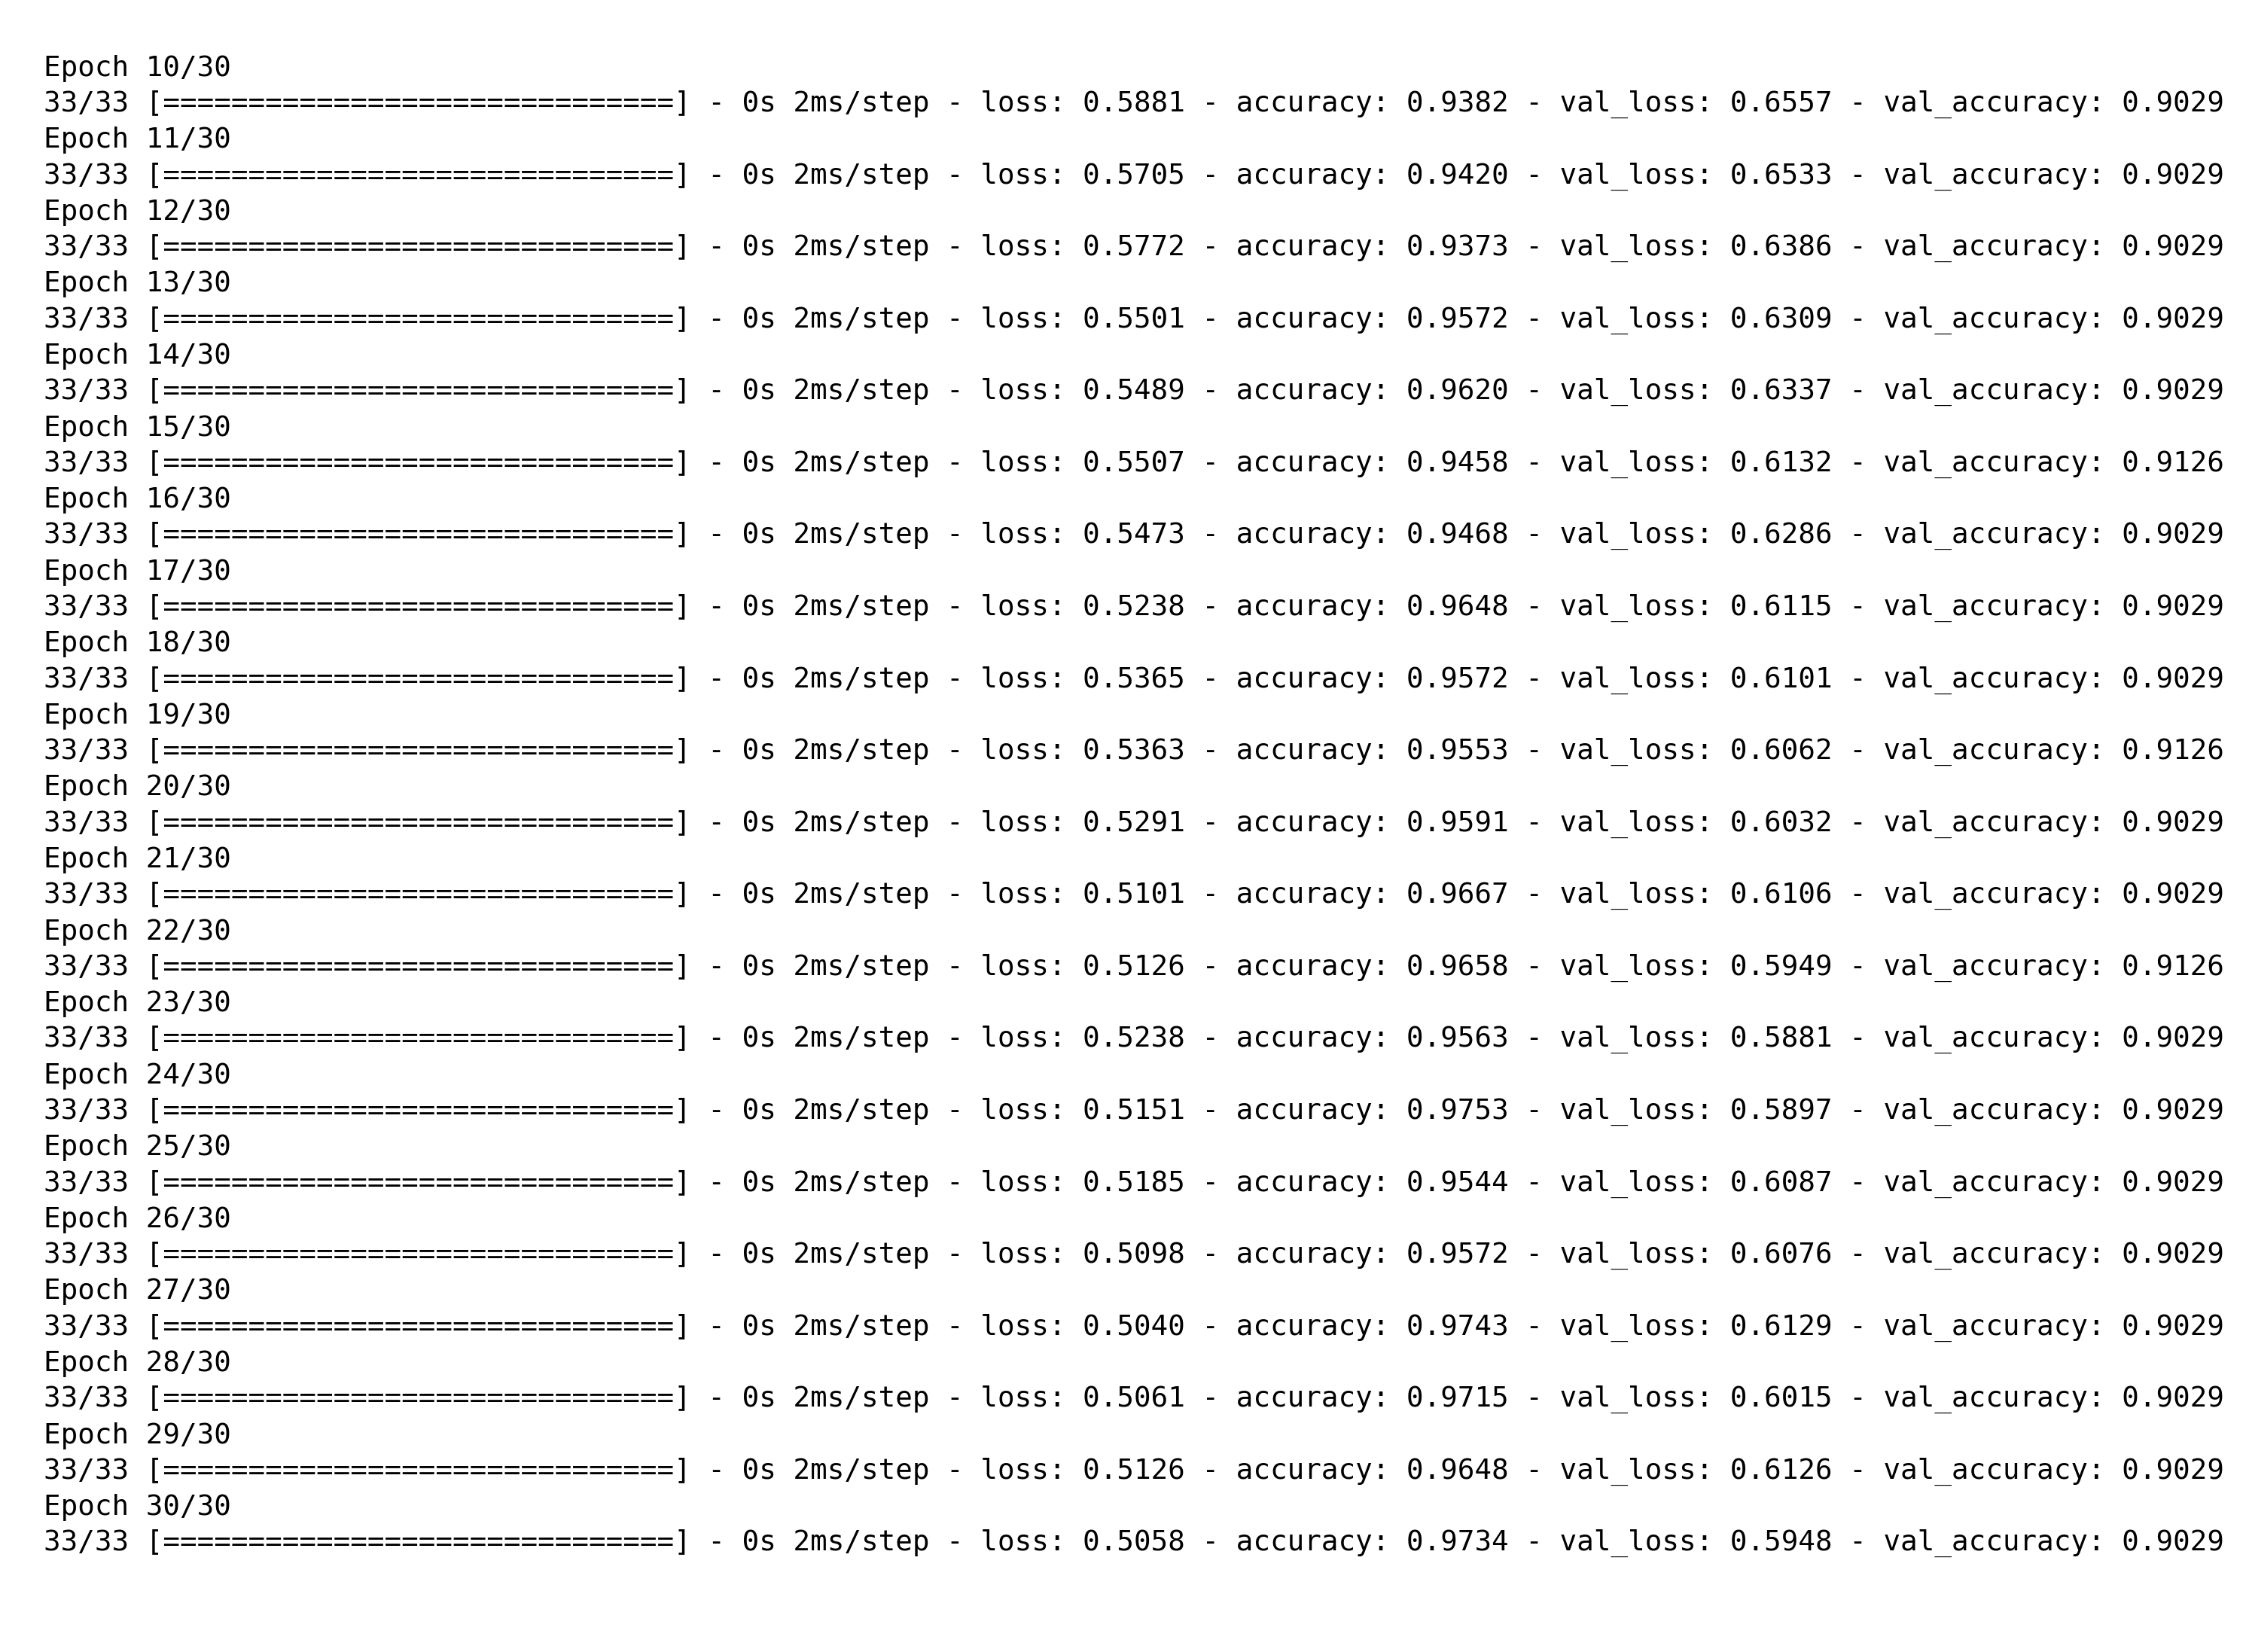

✓ Saved terminal log visual to: nn_training_console_logs.png


In [15]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. RECONSTRUCT THE KÉRAS CONSOLE TEXT FORMAT
# ---------------------------------------------------------------------
console_text = ""
total_epochs = len(train_loss_history)

# Define which epochs you want to display in the image snippet
# (e.g., last 20 epochs to match your screenshot window cleanly)
start_epoch = max(1, total_epochs - 20)

for ep in range(start_epoch, total_epochs + 1):
    idx = ep - 1  # List index conversion

    # Format accuracy values back to decimals if stored as percentages
    t_acc = train_acc_history[idx] / 100.0 if train_acc_history[idx] > 1.0 else train_acc_history[idx]
    v_acc = val_acc_history[idx] / 100.0 if val_acc_history[idx] > 1.0 else val_acc_history[idx]

    t_loss = train_loss_history[idx]
    v_loss = val_loss_history[idx]

    # Construct the two-line output structure seen in standard training logs
    console_text += f"Epoch {ep}/{total_epochs}\n"
    console_text += f"33/33 [==============================] - 0s 2ms/step - loss: {t_loss:.4f} - accuracy: {t_acc:.4f} - val_loss: {v_loss:.4f} - val_accuracy: {v_acc:.4f}\n"

# ---------------------------------------------------------------------
# 2. RENDER RAW TEXT LAYER TO HIGH-RESOLUTION CANVAS
# ---------------------------------------------------------------------
# Dynamically scale the image height based on the number of epochs being printed
num_lines = (total_epochs + 1 - start_epoch) * 2
calculated_height = max(4.0, num_lines * 0.22)

fig, ax = plt.subplots(figsize=(12, calculated_height), dpi=300)

# Render the console text block using a fixed-width terminal font layout
ax.text(0.01, 0.98, console_text, family='monospace', fontsize=9,
        va='top', ha='left', wrap=False, linespacing=1.4)

ax.axis('off')  # Strip out background axis lines

# Save out to your Colab workspace sidebar
output_file = "nn_training_console_logs.png"
plt.savefig(output_file, bbox_inches='tight', dpi=300, pad_inches=0.15)
plt.show()

print(f"✓ Saved terminal log visual to: {output_file}")

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Training Model 2: Random Forest...")

# Instantiate Random Forest with matching random state parameters
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Fit on resampled training data
rf_model.fit(X_train_resampled, y_train_resampled)

# Predict on validation data
y_val_pred_rf = rf_model.predict(X_val_scaled)
rf_val_acc = accuracy_score(y_val, y_val_pred_rf) * 100

print(f"✓ Model 2 (Random Forest) Validation Accuracy: {rf_val_acc:.2f}%")
from xgboost import XGBClassifier

print("Training Model 3: XGBoost...")

# Instantiate XGBoost targeting multi-class optimization paths
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    eval_metric='mlogloss',
    random_state=42
)

# Fit model
xgb_model.fit(X_train_resampled, y_train_resampled)

# Evaluate performance
y_val_pred_xgb = xgb_model.predict(X_val_scaled)
xgb_val_acc = accuracy_score(y_val, y_val_pred_xgb) * 100

print(f"✓ Model 3 (XGBoost) Validation Accuracy: {xgb_val_acc:.2f}%")
import pandas as pd

# Extract final validation score for PyTorch model
nn_model.eval()
with torch.no_grad():
    all_val_inputs = torch.tensor(X_val_scaled).float()
    nn_outputs = nn_model(all_val_inputs)
    _, nn_preds = torch.max(nn_outputs, 1)
    nn_val_acc = accuracy_score(y_val, nn_preds.numpy()) * 100

# Compile scoreboard
summary_data = {
    'Model Architecture': ['PyTorch NN (9->8->4->4)', 'Random Forest', 'XGBoost'],
    'Validation Accuracy': [f"{nn_val_acc:.2f}%", f"{rf_val_acc:.2f}%", f"{xgb_val_acc:.2f}%"]
}

summary_df = pd.DataFrame(summary_data)
print("\n=== FINAL 9-FEATURE PERFORMANCE COMPARISON ===")
print(summary_df.to_string(index=False))

Training Model 2: Random Forest...
✓ Model 2 (Random Forest) Validation Accuracy: 91.26%
Training Model 3: XGBoost...
✓ Model 3 (XGBoost) Validation Accuracy: 89.32%

=== FINAL 9-FEATURE PERFORMANCE COMPARISON ===
     Model Architecture Validation Accuracy
PyTorch NN (9->8->4->4)              90.29%
          Random Forest              91.26%
                XGBoost              89.32%


In [22]:
import time
import torch

# Assuming you already have:
# nn_model, criterion, optimizer, train_loader, val_loader, and total_epochs defined

print("Starting Training Run...")
total_epochs = 100

for epoch in range(1, total_epochs + 1):
    nn_model.train()
    start_time = time.time()

    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # Track steps within the epoch
    steps_in_epoch = len(train_loader)

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        optimizer.zero_grad()

        # Forward pass
        outputs = nn_model(inputs)
        loss = criterion(outputs, targets)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Track statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    # Calculate Epoch Training Metrics
    epoch_loss = running_loss / total_train
    epoch_acc = correct_train / total_train

    # Calculate Step Time in Milliseconds
    elapsed_time = time.time() - start_time
    ms_per_step = int((elapsed_time / steps_in_epoch) * 1000)
    round_seconds = int(round(elapsed_time))

    # --- VALIDATION PHASE ---
    nn_model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = nn_model(inputs)
            loss = criterion(outputs, targets)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val

    # --- EXPLICIT PATTERN PRINTING BLOCK ---
    # Matches the formatting: Epoch X/100 -> Progress Bar -> step time -> metrics
    print(f"Epoch {epoch}/{total_epochs}")

    # Creates a full Keras-style 30-character progress bar [====================]
    progress_bar = "=" * 30

    print(f"{steps_in_epoch}/{steps_in_epoch} [{progress_bar}] - "
          f"{round_seconds}s {ms_per_step}ms/step - "
          f"loss: {epoch_loss:.4f} - "
          f"accuracy: {epoch_acc:.4f} - "
          f"val_loss: {epoch_val_loss:.4f} - "
          f"val_accuracy: {epoch_val_acc:.4f}")

    # Save histories for your plotting dashboard cell
    train_loss_history.append(epoch_loss)
    train_acc_history.append(epoch_acc * 100) # Percentage matching your dashboard
    val_loss_history.append(epoch_val_loss)
    val_acc_history.append(epoch_val_acc * 100)

Starting Training Run...
Epoch 1/100
33/33 [==============================] - 0s 8ms/step - loss: 0.4872 - accuracy: 0.9705 - val_loss: 0.5899 - val_accuracy: 0.9029
Epoch 2/100
33/33 [==============================] - 0s 5ms/step - loss: 0.4809 - accuracy: 0.9715 - val_loss: 0.5899 - val_accuracy: 0.9029
Epoch 3/100
33/33 [==============================] - 0s 9ms/step - loss: 0.4870 - accuracy: 0.9677 - val_loss: 0.5899 - val_accuracy: 0.9029
Epoch 4/100
33/33 [==============================] - 0s 5ms/step - loss: 0.5045 - accuracy: 0.9572 - val_loss: 0.5899 - val_accuracy: 0.9029
Epoch 5/100
33/33 [==============================] - 0s 7ms/step - loss: 0.4945 - accuracy: 0.9677 - val_loss: 0.5899 - val_accuracy: 0.9029
Epoch 6/100
33/33 [==============================] - 0s 5ms/step - loss: 0.4772 - accuracy: 0.9743 - val_loss: 0.5899 - val_accuracy: 0.9029
Epoch 7/100
33/33 [==============================] - 0s 4ms/step - loss: 0.4862 - accuracy: 0.9667 - val_loss: 0.5899 - val_accur

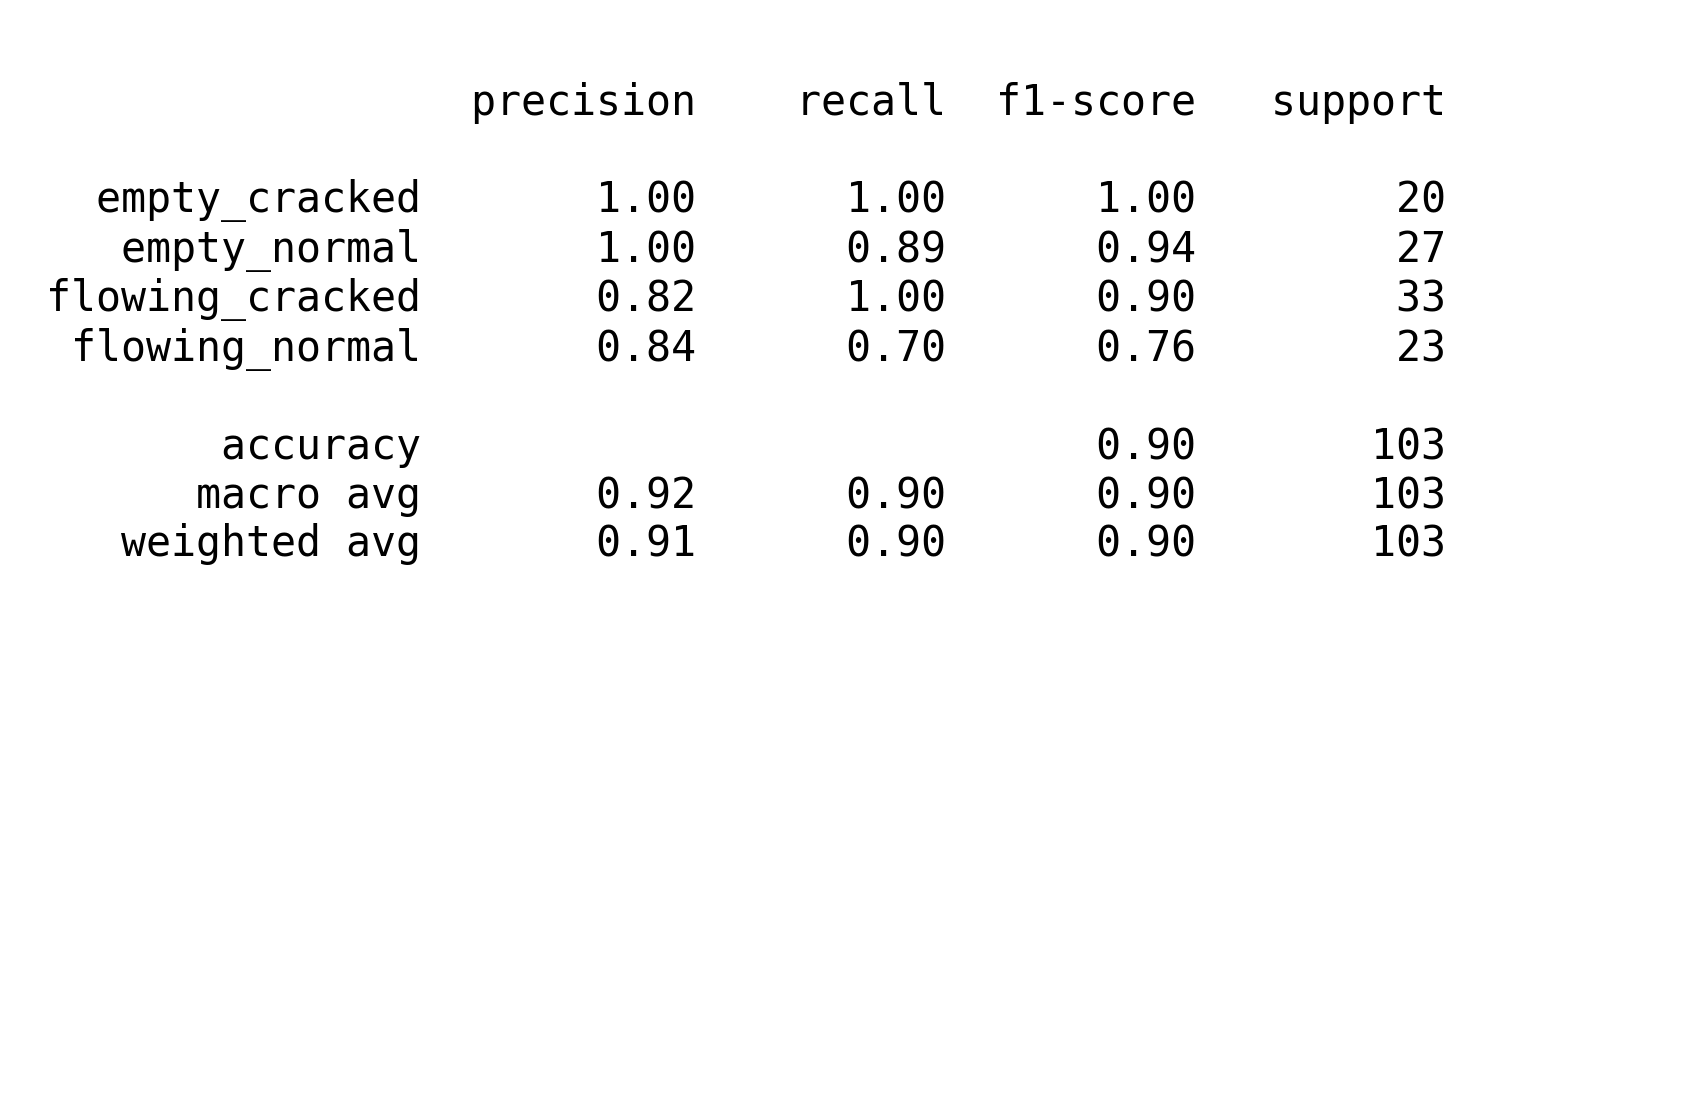

✓ Saved the raw text report as a PNG to your sidebar: standard_nn_classification_report.png


In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# 1. Generate the standard classification report text completely unchanged
ordered_classes = ['empty_cracked', 'empty_normal', 'flowing_cracked', 'flowing_normal']
raw_report_text = classification_report(y_val, y_pred_nn, target_names=ordered_classes)

# 2. Render this exact raw text output onto a high-resolution canvas
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)

# Using a fixed-width font keeps the standard terminal spaces aligned perfectly
ax.text(0.01, 0.95, raw_report_text, family='monospace', fontsize=10, va='top', ha='left')
ax.axis('off')  # Turn off plot axis lines

# 3. Save directly to your sidebar workspace
output_image_name = "standard_nn_classification_report.png"
plt.savefig(output_image_name, bbox_inches='tight', dpi=300, pad_inches=0.3)
plt.show()

print(f"✓ Saved the raw text report as a PNG to your sidebar: {output_image_name}")

In [ ]:
# Assuming you have completed your training loop and saved histories:
# train_acc_history, val_acc_history, train_loss_history are lists of values

file_name = "epoch_table_mlp.txt"

# Open the file to write the table structure
with open(file_name, "w") as f:

    # Helper function to send text to both the console and the file
    def log_row(text):
        print(text)
        f.write(text + "\n")

    log_row("\nFig 4.3.2: Epoch Table for Multilayer Perceptron (MLP)")
    log_row("=" * 70)
    log_row(f"{'Epoch':^12} | {'Training Accuracy (%)':^23} | {'Validation Accuracy (%)':^25} | {'Training Loss':^15}")
    log_row("-" * 70)

    # Print and save a row every 10 epochs
    for ep in range(10, len(train_loss_history) + 1, 10):
        idx = ep - 1 # Adjust for 0-indexed python lists

        t_acc = f"{train_acc_history[idx]:.2f}"
        v_acc = f"{val_acc_history[idx]:.2f}"
        t_loss = f"{train_loss_history[idx]:.2f}"

        log_row(f"{ep:^12} | {t_acc:^23} | {v_acc:^25} | {t_loss:^15}")

    log_row("=" * 70)

print(f"✓ Saved epoch summary table to: {file_name}")


Fig 4.3.2: Epoch Table for Multilayer Perceptron (MLP)
   Epoch     |  Training Accuracy (%)  |  Validation Accuracy (%)  |  Training Loss 
----------------------------------------------------------------------
     10      |          93.44          |           88.35           |      0.57      
     20      |          95.15          |           88.35           |      0.52      
     30      |          96.39          |           88.35           |      0.50      
     40      |          96.48          |           90.29           |      0.49      
     50      |          98.38          |           92.23           |      0.48      
     60      |          97.24          |           89.32           |      0.48      
     70      |          97.24          |           93.20           |      0.48      
     80      |          97.62          |           93.20           |      0.48      
     90      |          98.48          |           92.23           |      0.47      
    100      |         

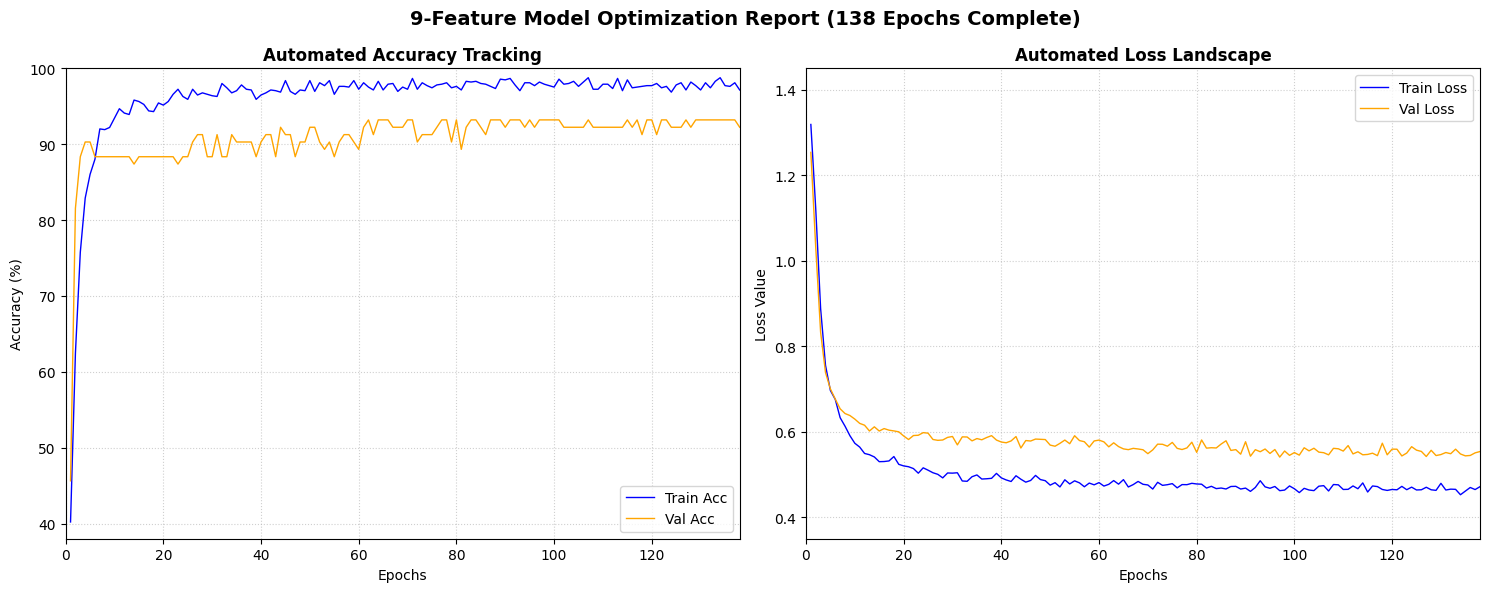

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

actual_epochs_completed = len(train_loss_history)
epochs_range = np.arange(1, actual_epochs_completed + 1)

# --- SMART TICK SPACING FIX ---
if actual_epochs_completed <= 20:
    tick_spacing = 2
elif actual_epochs_completed <= 100:
    tick_spacing = 10
elif actual_epochs_completed <= 200:
    tick_spacing = 20
else:
    tick_spacing = 50

# Extract boundaries for precise grid scaling
min_loss_val = min(min(train_loss_history), min(val_loss_history))
max_loss_val = max(max(train_loss_history), max(val_loss_history))
min_acc_val = min(min(train_acc_history), min(val_acc_history))
max_acc_val = max(max(train_acc_history), max(val_acc_history))

acc_bottom = max(0, np.floor(min_acc_val) - 2)
acc_top = min(100, np.ceil(max_acc_val) + 2)
loss_bottom = np.floor(min_loss_val * 10) / 10 - 0.05
loss_top = np.ceil(max_loss_val * 10) / 10 + 0.05

# --- CREATE 2-PANEL CANVAS ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"9-Feature Model Optimization Report ({actual_epochs_completed} Epochs Complete)", fontsize=14, fontweight='bold')

# PANEL 1: Accuracy Tracking
axes[0].plot(epochs_range, train_acc_history, label='Train Acc', color='blue', linewidth=1)
axes[0].plot(epochs_range, val_acc_history, label='Val Acc', color='orange', linewidth=1)
axes[0].set_title('Automated Accuracy Tracking', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=10)
axes[0].set_ylabel('Accuracy (%)', fontsize=10)
axes[0].set_ylim(acc_bottom, acc_top)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower right')

# PANEL 2: Loss Landscape
axes[1].plot(epochs_range, train_loss_history, label='Train Loss', color='blue', linewidth=1)
axes[1].plot(epochs_range, val_loss_history, label='Val Loss', color='orange', linewidth=1)
axes[1].set_title('Automated Loss Landscape', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=10)
axes[1].set_ylabel('Loss Value', fontsize=10)
axes[1].set_ylim(loss_bottom, loss_top)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper right')

# Apply the clean X-axis limits and labels to both graphs systematically
for ax in axes:
    ax.set_xlim(0, actual_epochs_completed)
    ax.set_xticks(np.arange(0, actual_epochs_completed + 1, tick_spacing))

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# List of your models and their predictions
models_eval = [
    ("Multilayer Perceptron (MLP)", y_pred_nn),
    ("Random Forest", y_val_pred_rf),
    ("XGBoost", y_val_pred_xgb)
]

ordered_classes = ['empty_cracked', 'empty_normal', 'flowing_cracked', 'flowing_normal']

for model_name, preds in models_eval:
    report = classification_report(y_val, preds, target_names=ordered_classes, output_dict=True)

    # Define a clean file name for each model
    safe_file_name = f"classification_report_{model_name.replace(' ', '_').replace('(', '').replace(')', '')}.txt"

    # Open the file to write the report into it
    with open(safe_file_name, "w") as f:

        # Helper function to print to BOTH screen and text file simultaneously
        def log(text):
            print(text)
            f.write(text + "\n")

        log(f"\nTable 1. Matrix of classification for the {model_name} model.")
        log("=" * 80)
        log(f"{'Words / Target Classes':<25} {'Precision':<12} {'Recall':<12} {'F1-score':<12} {'Support':<8}")
        log("-" * 80)

        for cls in ordered_classes:
            p = f"{report[cls]['precision']:.2f}"
            r = f"{report[cls]['recall']:.2f}"
            f1 = f"{report[cls]['f1-score']:.2f}"
            supp = int(report[cls]['support'])
            log(f"{cls:<25} {p:<12} {r:<12} {f1:<12} {supp:<8}")

        log("-" * 80)
        acc_f1 = f"{report['accuracy']:.2f}"
        total_supp = int(report['macro avg']['support'])
        log(f"{'Accuracy':<25} {'-':<12} {'-':<12} {acc_f1:<12} {total_supp:<8}")

        for avg_type in ['macro avg', 'weighted avg']:
            label = 'Macro average' if avg_type == 'macro avg' else 'Weighted average'
            p = f"{report[avg_type]['precision']:.2f}"
            r = f"{report[avg_type]['recall']:.2f}"
            f1 = f"{report[avg_type]['f1-score']:.2f}"
            log(f"{label:<25} {p:<12} {r:<12} {f1:<12} {total_supp:<8}")

        log("=" * 80)

    print(f"✓ Saved text report to: {safe_file_name}")


Table 1. Matrix of classification for the Multilayer Perceptron (MLP) model.
Words / Target Classes    Precision    Recall       F1-score     Support 
--------------------------------------------------------------------------------
empty_cracked             1.00         1.00         1.00         20      
empty_normal              1.00         0.93         0.96         27      
flowing_cracked           0.85         1.00         0.92         33      
flowing_normal            0.89         0.74         0.81         23      
--------------------------------------------------------------------------------
Accuracy                  -            -            0.92         103     
Macro average             0.94         0.92         0.92         103     
Weighted average          0.93         0.92         0.92         103     
✓ Saved text report to: classification_report_Multilayer_Perceptron_MLP.txt

Table 1. Matrix of classification for the Random Forest model.
Words / Target Classes    Pr